In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from functions_for_simulation import *

In [7]:
## initializing

np.random.seed(10)

rowNum, colNum = (300, 100)

Xs = Xs_generator(rowNum, colNum)
# Xs = np.random.normal(0, 4, n)
Ws_1 = np.ones(rowNum) 
Ws_0 = np.zeros(rowNum)

Ys_1 = Ys_generator(Xs, Ws_1)
Ys_0 = Ys_generator(Xs, Ws_0)

tau = np.average(Ys_1['y']) - np.average(Ys_0['y'])
# # If we use the same eps, tau will be the constant 1.0 

print("The average treatment effect tau: {0:.3f}".format(tau))

The average treatment effect tau: 1.883


t-statistic: 0.43970734146446283, p-value: 0.6604677935159279
不能拒绝原假设，即没有足够的证据表明两个样本的均值不相等。


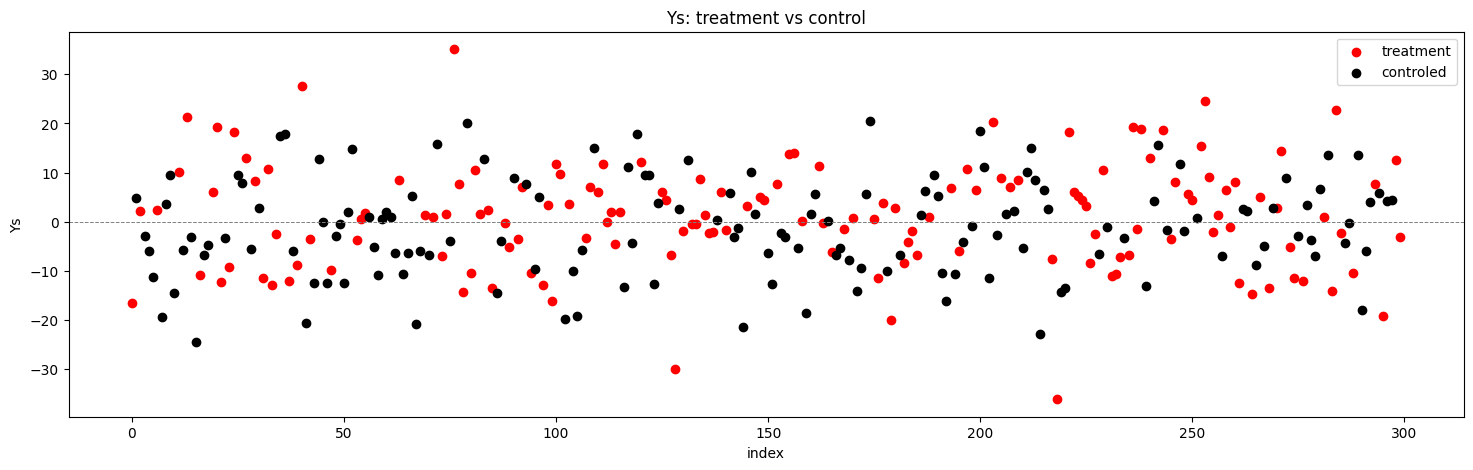

In [21]:
Ws_AAtest = Ws_generator_AAtest(Xs, 0.1)
df_AAtest = Ys_generator(Xs, Ws_AAtest)
randomization_output_plot(df_AAtest)

t-statistic: 0.3090053144930564, p-value: 0.7575334101116278
不能拒绝原假设，即没有足够的证据表明两个样本的均值不相等。
t-statistic: 0.8022861382241506, p-value: 0.423026793869852
不能拒绝原假设，即没有足够的证据表明两个样本的均值不相等。
t-statistic: 1.357583565393611, p-value: 0.17562301257628196
不能拒绝原假设，即没有足够的证据表明两个样本的均值不相等。
t-statistic: 0.15403926361338857, p-value: 0.8776830428159368
不能拒绝原假设，即没有足够的证据表明两个样本的均值不相等。
t-statistic: -0.05750861687447885, p-value: 0.9541785837440064
不能拒绝原假设，即没有足够的证据表明两个样本的均值不相等。
t-statistic: 1.758738583402215, p-value: 0.07964827828135215
拒绝原假设，即两个样本的均值不相等, Ws:[1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 0 0 1 1 0 0 1 0 1 1 1 0 1 0 1 0
 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 1 0 0 0 1
 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0 1
 1 0 1 1 0 1 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 1 1 1 0 1 1
 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 1 0 0
 0 0 0 0 1 1 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 1 1 0 1 1 1 1
 0 1 0 0 0

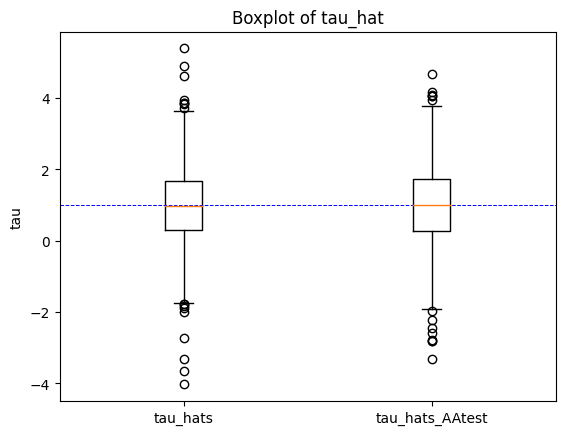

In [26]:
iterNum = 1000

tau_hats = []
for i in range(iterNum):
    Ws = Ws_generator_equal_size(Xs)
    df = Ys_generator(Xs, Ws)
    tau_hats.append(tau_hat_calculator(df))
    # print("The estimated average treatment effect tau_hat {0:.3f} with Ws {1}.".format(tau_hat, Ws))

tau_hats_AAtest = []
for i in range(iterNum):
    Ws = Ws_generator_AAtest(Xs, 0.1)
    df = Ys_generator(Xs, Ws)
    tau_hats_AAtest.append(tau_hat_calculator(df))

# boxplot
plt.boxplot([tau_hats, tau_hats_AAtest])
plt.xticks([1, 2], ['tau_hats', 'tau_hats_AAtest'])
# plt.boxplot(tau_hats_rerandomization)
plt.title('Boxplot of tau_hat')

# plt.axhline(y=3, color='blue', linestyle='--')
plt.axhline(y=1, color='blue', linestyle='--', linewidth = 0.7)

# add axis label
plt.ylabel('tau')

plt.show()